<a href="https://colab.research.google.com/github/enrico-s01/My-Git/blob/main/Copia_di_Asian_option_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0. Introduction to the Model for the Asian option with fixed strike.

In this section we consider an arithmetic Asian option written on a stock
whose price follows the Black-Scholes dynamics under the risk neutral measure.
We introduce the two dimensional process
$$
X_t := (S_t, A_t), \qquad t \in [0,T],
$$
where $S_t$ is the price of the underlying asset and $A_t$ is the arithmetic
average of the price accumulated up to time $t$. Starting from this process,
we rigorously derive the partial differential equation satisfied by the price
of the Asian option.

## Model for the stock price $S_t$ under the risk neutral measure

We consider a filtered probability space
$$
(\Omega, \mathcal{F}, (\mathcal{F}_t)_{t \in [0,T]}, \mathbb{Q}),
$$
where $(\mathcal{F}_t)$ is the filtration generated by a standard Brownian motion
$W = (W_t)_{t \in [0,T]}$ and completed in the usual sense, and $\mathbb{Q}$ is
a probability measure equivalent to the real-world measure $\mathbb{P}$, chosen
so that $\mathbb{Q}$ is a risk neutral measure.

Under the measure $\mathbb{Q}$, we assume that the stock price process
$S = (S_t)_{t \in [0,T]}$ follows the Black-Scholes model:
$$
  dS_t = r S_t \, dt + \sigma S_t \, dW_t,
  \qquad t \in [0,T],
$$
where:
- $r > 0$ is the risk-free interest rate (constant);
- $\sigma > 0$ is the volatility of the stock (also constant);
- $W_t$ is a standard Brownian motion under $\mathbb{Q}$.

We also impose the initial condition
$$
S_0 = s_0 > 0 .
$$

The stochastic differential equation for $S_t$ written above admits a unique strong
solution, explicitly given by
$$
S_t = S_0 \exp\!\left( \Big(r - \tfrac{1}{2}\sigma^2\Big) t + \sigma W_t \right),
\qquad t \in [0,T],
$$
which in particular guarantees that $S_t > 0$ for all $t$ almost surely.
This process is an Itô process adapted to the filtration $(\mathcal{F}_t)$.

## Definition of the arithmetic average $A_t$ and its dynamics

In the case of an arithmetic Asian option, the payoff depends on the
arithmetic average of the prices observed over the time horizon.
In the present setting, for each $t \in (0,T]$, we consider the arithmetic
average of the underlying price accumulated up to time $t$:
$$
  A_t := \frac{1}{t} \int_0^t S_\tau \, d\tau,
  \qquad t \in (0,T].
$$
By definition, the process $A = (A_t)_{t \in (0,T]}$ is a functional of the path of $S$:
given the entire path $(S_\tau)_{\tau \in [0,t]}$, the value $A_t$ is deterministic.
In particular, $A_t$ does not contain its own Brownian noise, in the sense that its
dynamics has no $dW_t$ term.

In order to use $A_t$ as a state variable, it is essential to determine its
differential equation (in the sense of Itô differentials). Starting from the
definition of $A_t$ given above, we observe that
$$
  t A_t = \int_0^t S_\tau \, d\tau.
$$
We compute the differential of the left-hand side using the Itô product rule
for the product of a deterministic function of time and an adapted process:
$$
d(t A_t) = A_t \, dt + t \, dA_t.
$$
On the other hand, the right-hand side is a deterministic integral in $\tau$,
so its differential with respect to the terminal time $t$ is
$$
d\!\left( \int_0^t S_\tau \, d\tau \right) = S_t \, dt.
$$
Equating the two differentials we obtain
$$
A_t \, dt + t \, dA_t = S_t \, dt,
$$
and isolating $dA_t$ gives
$$
t \, dA_t = (S_t - A_t) \, dt
\qquad \Longrightarrow \qquad
dA_t = \frac{S_t - A_t}{t} \, dt,
\quad t \in (0,T].
$$
The dynamics of $A_t$ is therefore purely deterministic given the process $S$:
$$
  dA_t = \frac{S_t - A_t}{t} \, dt,
  \qquad t \in (0,T].
$$
We note that:
- no $dW_t$ term appears in the dynamics of $A_t$;
- given a realization of $S$, the process $A$ is completely determined
  through the integral representation of $A_t$ given above.

The definition of $A_t$ can be continuously extended to $t=0$ by setting
$A_0 := S_0$, but for the derivation of the PDE we will work on $t \in (0,T)$ and
we will view the time $t = 0$ as a boundary of the time domain.

## The two dimensional process $X_t = (S_t, A_t)$

We now combine the dynamics of $S_t$ and $A_t$.
From the Black-Scholes dynamics for $S_t$ and the dynamics of $A_t$ derived above we have
$$
  \begin{cases}
    dS_t = r S_t \, dt + \sigma S_t \, dW_t, \\[4pt]
    dA_t = \dfrac{S_t - A_t}{t} \, dt,
  \end{cases}
  \qquad t \in (0,T].
$$
We then define the two-dimensional process
$$
X_t := (S_t, A_t)^\top, \qquad t \in (0,T].
$$
The system can be written in vector form as
$$
  dX_t =
  \begin{pmatrix}
    dS_t \\
    dA_t
  \end{pmatrix}
  =
  \begin{pmatrix}
    r S_t \\[4pt]
    \dfrac{S_t - A_t}{t}
  \end{pmatrix} dt
  +
  \begin{pmatrix}
    \sigma S_t \\
    0
  \end{pmatrix} dW_t.
$$
The process $X = (X_t)_{t \in (0,T]}$ is an Itô process taking values in
$(0,\infty) \times (0,\infty)$, adapted to the filtration $(\mathcal{F}_t)$.
It is a (two-dimensional) Markov process, non-homogeneous in time because of the
explicit factor $1/t$ appearing in the drift of $A_t$.




# 1. Derivation of the pricing PDE for the Asian option

We now derive the partial differential equation satisfied by the price of the
Asian option written on the two-dimensional state process
$$
X_t := (S_t, A_t)^\top, \qquad t \in (0,T],
$$
whose dynamics under the risk neutral measure $\mathbb{Q}$ is given by
$$
  \begin{cases}
    dS_t = r S_t \, dt + \sigma S_t \, dW_t, \\[4pt]
    dA_t = \dfrac{S_t - A_t}{t} \, dt,
  \end{cases}
  \qquad t \in (0,T].
$$
The option has maturity $T>0$ and payoff
$$
\varphi(S_T,A_T),
$$
where typically $\varphi$ is of the form $\varphi(S_T,A_T) = (A_T - K)^+$ for a
fixed strike $K>0$, but the derivation below does not depend on the specific choice
of $\varphi$.

### Risk neutral valuation

Under the risk neutral measure $\mathbb{Q}$, the price of the option at time $t$ is:
$$
V_t = \mathbb{E}^{\mathbb{Q}}\!\left[ e^{-r(T-t)} \varphi(S_T,A_T)
       \,\big|\, \mathcal{F}_t \right].
$$
By definition of risk neutral measure, the discounted price process
$e^{-rt} V_t$ must be a martingale with respect to the filtration
$(\mathcal{F}_t)$.

Our goal is to use this martingale property to obtain the PDE
stated in the assignment, namely
$$
\begin{cases}
-\,\partial_t V(t,s,a)
- \dfrac{1}{2}\sigma^2 s^2 \partial_{ss} V(t,s,a)
- r s \, \partial_s V(t,s,a)
- \dfrac{s-a}{t} \partial_a V(t,s,a)
+ r V(t,s,a) = 0, \\[4pt]
V(T,s,a) = \varphi(s,a),
\end{cases}
$$
for $t \in [0,T)$, $s>0$, $a>0$.

### Application of Itô's formula to $V(t,S_t,A_t)$

Let $V \in C^{1,2,1}\big([0,T]\times (0,\infty)\times (0,\infty)\big)$, that is,
$V$ is once continuously differentiable in $t$ and $a$, and twice in $s$.
Applying the multidimensional Itô formula to the function
$$
(t,s,a) \longmapsto V(t,s,a)
$$
along the two-dimensional Itô process $X_t = (S_t,A_t)$, and noting that the
second-order terms involving $dA_t$ (i.e.
$\tfrac{1}{2}\partial_{aa}V(t,S_t,A_t)(dA_t)^2$ and
$\partial_{sa}V(t,S_t,A_t)\,dS_t dA_t$) vanish because $dA_t$ has no diffusion term (so $(dA_t)^2 = 0$ and $dS_t dA_t = 0$ in the Itô sense), we obtain
$$
  dV(t,S_t,A_t)
  = \partial_t V(t,S_t,A_t)\, dt
   + \partial_s V(t,S_t,A_t)\, dS_t
   + \partial_a V(t,S_t,A_t)\, dA_t
   + \frac{1}{2} \partial_{ss} V(t,S_t,A_t) \, (dS_t)^2.
$$

Substituting $dS_t$ and $dA_t$ from the dynamics of $(S_t,A_t)$ written above and using
$(dW_t)^2 = dt$ and $dW_t\,dt = dt^2 = 0$, we get
$$
  dV(t,S_t,A_t)
  = \partial_t V(t,S_t,A_t)\, dt
   + \partial_s V(t,S_t,A_t)\big( r S_t \, dt + \sigma S_t \, dW_t \big)
   + \partial_a V(t,S_t,A_t)\, \frac{S_t - A_t}{t}\, dt
   + \frac{1}{2} \partial_{ss} V(t,S_t,A_t) \big( \sigma^2 S_t^2 \, dt \big).
$$
Equivalently,
$$
  dV(t,S_t,A_t)
  = \Big(
      \partial_t V
      + r S_t \partial_s V
      + \frac{S_t - A_t}{t} \partial_a V
      + \frac{1}{2}\sigma^2 S_t^2 \partial_{ss} V
     \Big)(t,S_t,A_t)\, dt
  + \sigma S_t \partial_s V(t,S_t,A_t)\, dW_t.
$$
For later convenience, we introduce the (time-dependent version) infinitesimal generator
$\mathcal{L}_t$ of the process $X_t = (S_t,A_t)$, acting on $f=f(t,s,a)$ as
$$
  (\mathcal{L}_t f)(t,s,a)
  := r s \, \partial_s f(t,s,a)
   + \frac{s-a}{t} \partial_a f(t,s,a)
   + \frac{1}{2} \sigma^2 s^2 \partial_{ss} f(t,s,a).
$$
Then the previous computation can be written compactly as
$$
  dV(t,S_t,A_t)
  = \big( \partial_t V + \mathcal{L}_t V \big)(t,S_t,A_t)\, dt
    + \sigma S_t \partial_s V(t,S_t,A_t)\, dW_t.
$$

### Discounted price and martingale condition

Consider now the discounted price process
$$
\widetilde{V}_t := e^{-rt} V(t,S_t,A_t), \qquad t \in [0,T].
$$
Using the Itô product rule we compute
$$
  d\widetilde{V}_t
  = d\big( e^{-rt} V(t,S_t,A_t) \big)
  = e^{-rt} \, dV(t,S_t,A_t)
     + V(t,S_t,A_t)\, d(e^{-rt})
     + d\langle e^{-rt}, V(t,S_t,A_t)\rangle_t.
$$
Since $e^{-rt}$ is a deterministic $C^1$ function of time, we have
$$
d(e^{-rt}) = -r e^{-rt}\, dt
\quad\text{and}\quad
d\langle e^{-rt}, V(t,S_t,A_t)\rangle_t = 0.
$$
Substituting the equation for $dV$ we obtain
$$
  d\widetilde{V}_t
  = e^{-rt}
     \big( \partial_t V + \mathcal{L}_t V \big)(t,S_t,A_t)\, dt
   + e^{-rt} \sigma S_t \partial_s V(t,S_t,A_t)\, dW_t
   - r e^{-rt} V(t,S_t,A_t)\, dt.
$$
That is,
$$
  d\widetilde{V}_t
  = e^{-rt}
     \big( \partial_t V + \mathcal{L}_t V - r V \big)(t,S_t,A_t)\, dt
   + e^{-rt} \sigma S_t \partial_s V(t,S_t,A_t)\, dW_t.
$$

By risk neutral pricing, the discounted price process
$\widetilde{V}_t = e^{-rt} V(t,S_t,A_t)$ must be a martingale under $\mathbb{Q}$.
For an Itô process of the form
$$
d\widetilde{V}_t = \mu_t \, dt + \nu_t \, dW_t
$$
to be a martingale, it is necessary and sufficient that its drift term vanish
identically, i.e.\ $\mu_t = 0$ almost surely for all $t$.
Hence we need
$$
\big( \partial_t V + \mathcal{L}_t V - r V \big)(t,S_t,A_t) = 0
\quad\text{for all } t \in [0,T), \text{ almost surely}.
$$
Since $(S_t,A_t)$ can take any value in $(0,\infty)\times(0,\infty)$,
we obtain the PDE
$$
  \partial_t V(t,s,a)
  + (\mathcal{L}_t V)(t,s,a)
  - r V(t,s,a) = 0,
  \qquad t \in [0,T),\; s>0,\; a>0.
$$
Writing explicitly we have exactly:
$$
-\,\partial_t V
- \frac{1}{2}\sigma^2 s^2 \partial_{ss} V
- r s \, \partial_s V
- \frac{s-a}{t} \partial_a V
+ r V = 0.
$$
The terminal condition comes directly from the payoff at maturity:
$$
V(T,s,a) = \varphi(s,a),
\qquad s>0,\; a>0.
$$

### Connection with the Feynman-Kac theorem

The argument above is in fact the standard probabilistic proof of
the Feynman-Kac representation formula.
In our setting, the Feynman-Kac theorem can be stated informally as follows.

> **Feynman-Kac representation**  
> Let $(X_t)_{t\in[0,T]}$ be a Markov diffusion process with generator
> $\mathcal{L}_t$, and let $r\ge 0$ be a constant.
> Consider the terminal value problem
> $$
> \begin{cases}
> \partial_t u(t,x) + (\mathcal{L}_t u)(t,x) - r u(t,x) = 0,
> & t \in [0,T),\ x \in \mathbb{R}^d, \\[4pt]
> u(T,x) = \varphi(x),
> & x \in \mathbb{R}^d,
> \end{cases}
> $$
> for a given payoff function $\varphi$.
>
> If $u$ is a sufficiently regular solution of this PDE, then
> $$
> u(t,x) = \mathbb{E}^{\mathbb{Q}}_{t,x}
> \!\left[ e^{-r(T-t)} \varphi(X_T) \right],
> $$
> where $\mathbb{E}^{\mathbb{Q}}_{t,x}$ denotes expectation under $\mathbb{Q}$
> given $X_t = x$. Conversely, if we define $u$ by the right-hand side above,
> then (under suitable regularity conditions) $u$ solves the PDE.

In our problem we have $X_t = (S_t,A_t)$, the generator $\mathcal{L}_t$, the discount rate $r$, and the payoff
$\varphi(S_T,A_T)$. Therefore, applying the Feynman-Kac theorem directly
to this setting yields that the function $V$ is the unique solution of the PDE for $V(t,s,a)$ derived above, with
terminal condition $V(T,s,a) = \varphi(s,a)$.


# 2. Interpretation of the fixed-strike Asian payoff

In our framework, we have a fixed-strike arithmetic Asian call option with maturity $T$ and
strike $K > 0$. Its payoff at time $T$ is given by
$$
 \varphi(S_T,A_T) = (A_T - K)_+,
$$

We now show that the Asian payoff $(A_T - K)_+$ can be rewritten in this form,
for a suitable choice of $L_T$.

Define the (random) strike
$$
 L_T := K - A_T + S_T.
$$
The payoff of a call on $S_T$ with strike $L_T$ is then
$$
 (S_T - L_T)_+
 = \big( S_T - (K - A_T + S_T) \big)_+.
$$
Using simple algebra inside the brackets, we obtain
$$
 S_T - (K - A_T + S_T)
 = S_T - K + A_T - S_T
 = A_T - K.
$$
Hence,
$$
 (S_T - L_T)_+
 = (A_T - K)_+.
$$
Therefore, the fixed-strike Asian call with payoff $(A_T - K)_+$ is
mathematically equivalent to a call option on the underlying $S_T$ with random
exercise price $K - A_T + S_T$ at maturity $T$.

From an economic point of view, this shows that at time $T$ the holder has a
right to buy the asset at the price $K - A_T + S_T$: exercising this
right yields the gain $A_T - K$,
which coincides exactly with the Asian payoff.


## Change of variables

We start from the pricing PDE for the Asian option:
$$
\begin{cases}
-\partial_t V
-\dfrac{1}{2}\sigma^2 S^2 \partial_{SS} V
- r S \, \partial_S V
- \dfrac{S-A}{t}\,\partial_A V
+ r V = 0, \\[4pt]
V(T,S,A) = (A-K)_+ ,
\end{cases}
\qquad S>0,\ A>0,\ t\in[0,T).
$$

and we introduce the backward time and a new spatial variable
$$
    \tau := T-t, \qquad
    x := \frac{K - \dfrac{t}{T}A}{S}.
$$

Now we look for a particular solution of the form
$$
V(t,S,A) = S\, f(\tau,x),
$$
for some function f.

We will begin by showing that $f$ must satisfy the following PDE:
$$
\partial_t f
- \frac12\sigma^2 x^2 \partial_{xx} f
+ \Big(\frac{1}{T} + r x\Big) \partial_x f = 0.
$$
All partial derivatives of V will be expressed in terms of derivatives of
f using the chain rule. Recall we need
$-\partial_t V$,
$ \partial_{SS} V$,
$\partial_S V$,
$\partial_A V$. Let's compute all these derivatives. By definition of $\tau$ and $x$, we have:
$$
\partial_t \tau = -1,\quad
\partial_S \tau = 0,\quad
\partial_A \tau = 0,
$$
$$
\partial_S x
= \frac{\partial}{\partial S}\Big(\frac{K - \dfrac{t}{T}A}{S}\Big)
= -\frac{x}{S},
$$

$$
\partial_A x
= \frac{\partial}{\partial A}\Big(\frac{K - \dfrac{t}{T}A}{S}\Big)
= -\frac{t}{TS}.
$$
$$
\partial_t x
= \frac{\partial}{\partial t}\Big(\frac{K - \dfrac{t}{T}A}{S}\Big)
= -\frac{A}{TS}.
$$

Now, using our assumption, the new variables and the chain rule, we obtain:

**First derivative with respect to S.**

$$
\partial_S V
= \partial_S(S f(\tau,x))
= f(\tau,x)
+ S\big(f_\tau \partial_S \tau + f_x \partial_S x\big)
= f - x f_x.
$$

Now, in order to comupte the second derivative with respect to $S$, we note:
$$
\partial_S f(\tau,x)
= f_\tau \partial_S\tau + f_x \partial_S x
= -\frac{x}{S} f_x.
$$
and,
$$
\partial_S(x f_x)
= (\partial_S x) f_x + x\, \partial_S f_x.
$$
and,
$$
\partial_S f_x
= f_{x\tau}\partial_S\tau + f_{xx}\partial_S x
= -\frac{x}{S} f_{xx}.
$$
Moreover,
$$
\partial_S(x f_x)
= \Big(-\frac{x}{S}\Big) f_x
+ x\Big(-\frac{x}{S} f_{xx}\Big)
= -\frac{x}{S} f_x - \frac{x^2}{S} f_{xx}.
$$
Thus we obtain the

**Second derivative with respect to $S$.**

$$
\partial_{SS} V
= \partial_S f - \partial_S(x f_x)
= -\frac{x}{S} f_x -\Big(-\frac{x}{S} f_x - \frac{x^2}{S}f_{xx}\Big)
= \frac{x^2}{S}\, f_{xx}.
$$

**Derivative with respect to $A$.**

$$
\partial_A V
= S\big(f_\tau \partial_A\tau + f_x \partial_A x\big)
= S\Big(0 + f_x \Big(-\frac{t}{TS}\Big)\Big)
= -\frac{t}{T} f_x.
$$

**Derivative with respect to $t$.**

$$
\partial_t V
= S\big(f_\tau \partial_t\tau + f_x \partial_t x\big)
= S\Big(f_\tau (-1) + f_x \Big(-\frac{A}{TS}\Big)\Big)
= -S f_\tau - \frac{A}{T} f_x.
$$

**Substitution into the original PDE.**  
We substitute the expressions above into the original PDE for $V(t,S,A)$ written at the beginning of this subsection.

First term:
$$
-\partial_t V
= S f_\tau + \frac{A}{T} f_x.
$$

Second term:
$$
-\frac12\sigma^2 S^2 \partial_{SS}V
= -\frac12\sigma^2 S x^2 f_{xx}.
$$

Third term:
$$
- rS\,\partial_S V
= -rS f + rS x f_x.
$$

Fourth term:
$$
-\frac{S-A}{t}\,\partial_A V
= \frac{S-A}{T} f_x.
$$

Fifth term:
$$
rV = r S f.
$$

Summing all terms in the original PDE we obtain
$$
\begin{aligned}
0
&= \big[ S f_\tau + \tfrac{A}{T} f_x \big]
   + \big[-\tfrac12\sigma^2 S x^2 f_{xx}\big]
   + \big[-rS f + rS x f_x\big]
   + \big[\tfrac{S-A}{T} f_x\big]
   + \big[r S f\big].
\end{aligned}
$$
The terms -rSf and +rSf cancel, and the coefficients in front of
$f_x$ simplify as
$$
\frac{A}{T} + \frac{S-A}{T} = \frac{S}{T}.
$$
Hence
$$
S f_\tau
- \frac12\sigma^2 S x^2 f_{xx}
+ \Big(\frac{S}{T} + r S x\Big) f_x = 0.
$$
Factoring out the strictly positive factor $S$, and renaming $\tau$ by $t$ we obtain exactly the reduced PDE for $f$:
$$
\partial_t f
- \frac12\sigma^2 x^2 \partial_{xx} f
+ \Big(\frac{1}{T} + r x\Big) \partial_x f = 0.
$$

**Initial condition for $f$.**  
At maturity $t = T$ we have $$\tau = T-t = 0.$$ Moreover,
$$
x(T,S,A)
= \frac{K - T A/T}{S}
= \frac{K-A}{S}.
$$
From the payoff condition,
$$
V(T,S,A) = (A-K)_+.
$$
Using our assumption: at $t=T$,
$$
V(T,S,A) = S f(0,x).
$$
We rewrite the payoff in terms of $x$:
$$
(A-K)_+
= \max(A-K,0)
= S \max\Big(\frac{A-K}{S},0\Big)
= S \max\Big(-\frac{K-A}{S},0\Big)
= S \max(-x,0)
= S x_-,
$$
where $x_- := \max(-x,0)$.
Thus
$$
S f(0,x) = S x_- \quad\Rightarrow\quad f(0,x) = x_-.
$$
This is precisely the initial condition corresponding to the reduced PDE for $f$ derived above.

**Expression of the sought value.**  
Finally, the quantity of interest is the option price at time $t=0$ when the
initial average equals the spot price, i.e.  $A_0 = S_0 = S$. At $t=0$,
$$
\tau = T-0 = T, \qquad
x(0,S,A_0=S) = \frac{K - 0\cdot A_0/T}{S} = \frac{K}{S}.
$$
Using the representation $V(t,S,A) = S f(\tau,x)$ we obtain
$$
\boxed{
V(0,S,S) = S\, f(T, x = K/S).
}
$$

We have thus derived in full detail the reduced PDE for $f$, its
initial condition $f(0,x)=x_-$, and the expression of the desired option
value in terms of the solution $f$.


# 3. Linear solution and approximate PDE on a bounded domain

We recall the reduced pricing PDE for the function $f$:
$$
\begin{cases}
\partial_t f(t,x)
- \dfrac{1}{2}\sigma^2 x^2 \partial_{xx} f(t,x)
+ \Big(\dfrac{1}{T} + r x\Big)\partial_x f(t,x) = 0,
& 0 < t \le T,\; x\in\mathbb{R},\\[4pt]
f(0,x) = x_- := \max(-x,0), & x\in\mathbb{R}.
\end{cases}
$$

### Auxiliary problem with linear initial condition

We first consider a simplified problem in which the initial condition is replaced by the purely linear function
$$
g(0,x) := -x, \qquad x\in\mathbb{R}.
$$
More precisely, we look for a function $g(t,x)$ satisfying
$$
\begin{cases}
\partial_t g
- \dfrac{1}{2}\sigma^2 x^2 g_{xx}
+ \Big(\dfrac{1}{T} + r x\Big) g_x = 0,\\[4pt]
g(0,x) = -x.
\end{cases}
$$
In particular we look for a solution of the form:
$$
g(t,x) = x\,a(t) + b(t),
$$
where $a(t)$ and $b(t)$ are time–dependent scalar functions to be determined.
Therefore, we compute the derivatives of $g$:
$$
\partial_t g(t,x) = x a'(t) + b'(t), \qquad
g_x(t,x) = a(t), \qquad
g_{xx}(t,x) = 0.
$$
Substituting these expressions into the PDE yields
$$
x a'(t) + b'(t)
- \frac{1}{2}\sigma^2 x^2 \cdot 0
+ \Big(\frac{1}{T} + r x\Big)a(t) = 0,
$$
that is
$$
x a'(t) + b'(t)
+ \frac{1}{T} a(t) + r x a(t) = 0.
$$
We now group separately the terms proportional to $x$ and the constant terms:
$$
\big(a'(t) + r a(t)\big)\,x
+ \big(b'(t) + \tfrac{1}{T} a(t)\big) = 0.
$$
Since this identity must hold for all $x\in\mathbb{R}$, both coefficients must
vanish, so $a(t)$ and $b(t)$ satisfy the system
$$
\begin{cases}
a'(t) + r a(t) = 0,\\[4pt]
b'(t) + \dfrac{1}{T} a(t) = 0.
\end{cases}
$$

The initial condition $g(0,x)=-x$ gives
$$
g(0,x) = x a(0) + b(0) = -x,
$$
so that
$$
a(0) = -1, \qquad b(0) = 0.
$$
We now solve the system above.

For $a(t)$ we have a first–order linear ODE
$$
a'(t) = -r a(t), \qquad a(0)=-1,
$$
whose solution is
$$
a(t) = -e^{-rt}, \qquad t\in[0,T].
$$
For $b(t)$ we obtain
$$
b'(t) = -\frac{1}{T} a(t)
= \frac{1}{T} e^{-rt}, \qquad b(0)=0.
$$
Integrating from $0$ to $t$ we find
$$
b(t)
= \frac{1}{T} \int_0^t e^{-rs}\,ds
= \frac{1}{T}\,\frac{1 - e^{-rt}}{r}
= \frac{1}{rT}\big(1 - e^{-rt}\big).
$$

Substituting $a(t)$ and $b(t)$ into the expression of $g$, we obtain the explicit
solution of the auxiliary problem:
$$
g(t,x)
= x a(t) + b(t)
= -x e^{-rt} + \frac{1}{rT}\big(1 - e^{-rt}\big).
$$
This is the explicit expression for $g(t,x)$ that we will refer to later.

### Asymptotic behaviour of the true solution $f$

Recall that the true function $f$ solves the PDE with initial
condition
$$
f(0,x) = x_- =
\begin{cases}
-x, & x<0,\\[2pt]
0, & x\ge 0.
\end{cases}
$$
Thus, for $x<0$, the initial condition for $f$ coincides with that of $g$,
while for $x\ge 0$ it is identically zero.

On the basis of the structure of the PDE and the initial data, we assume that:

- for large positive $x$,
  $$
  \lim_{x\to+\infty} f(t,x) = 0;
  $$
  this reflects the fact that the initial condition vanishes for $x\ge 0$
  and the PDE does not create positive mass at $+\infty$;
- for large negative $x$,
  $$
  f(t,x) \sim g(t,x) \qquad \text{as } x\to -\infty,
  $$
  i.e. the behaviour of $f$ is asymptotically the same as that of the
  linear solution $g$ given by the explicit formula for $g(t,x)$ above. This is natural since, in
  the far left region where $x\ll 0$, the initial conditions of $f$ and
  $g$ coincide and both evolve under the same linear PDE.

These asymptotic properties will be used to construct boundary conditions on a
finite spatial domain.

### Approximate PDE on a bounded spatial interval

For numerical purposes it is not convenient to work on the whole real line
$x\in\mathbb{R}$. We therefore restrict the spatial domain to a finite interval
$$
x \in [X_{\min}, X_{\max}],
$$
with
$$
X_{\min} \le 0, \qquad X_{\max} > \bar x := \frac{K}{S},
$$
so that the point $\bar x = K/S$ at which we finally evaluate $f$ lies in the
interior of the computational domain.

Using the asymptotic behaviour described above, we approximate the behaviour of
$f$ at $\pm\infty$ by boundary conditions at $X_{\min}$ and $X_{\max}$:

- as $x\to +\infty$, $f(t,x)\to 0$ suggests the right boundary condition
  $$
  f(t,X_{\max}) = 0, \qquad 0 < t \le T;
  $$
- as $x\to -\infty$, $f(t,x)\sim g(t,x)$ suggests the left boundary
  condition
  $$
  f(t,X_{\min}) = g(t,X_{\min})
  = -X_{\min} e^{-rt} + \frac{1}{rT}\big(1 - e^{-rt}\big),
  \qquad 0 < t \le T.
  $$

We thus obtain the following approximate boundary value problem for $f$
on the bounded domain $[X_{\min},X_{\max}]$:
$$
\begin{cases}
\partial_t f(t,x)
- \dfrac{1}{2}\sigma^2 x^2 \partial_{xx} f(t,x)
+ \Big(\dfrac{1}{T} + r x\Big)\partial_x f(t,x) = 0,
& 0<t\le T,\; X_{\min}<x<X_{\max},\\[6pt]
f(0,x) = x_- = \max(-x,0),
& X_{\min}\le x\le X_{\max},\\[6pt]
f(t,X_{\max}) = 0,
& 0<t\le T,\\[4pt]
f(t,X_{\min}) = g(t,X_{\min}),
& 0<t\le T,
\end{cases}
$$
where $g$ is given explicitly by the formula for $g(t,x)$ derived earlier.

This is the approximate PDE on a finite spatial
interval required in point 3, with boundary conditions chosen to reflect the
asymptotic behaviour of the exact solution $f$ at $\pm\infty$.


#4. Numerical Resolution of the PDE

This is our original problem

$$
\left\{\begin{matrix} \partial_t f(t,x)- \dfrac{1}{2}\sigma^2 x^2 \partial_{xx} f(t,x)+ \Big(\dfrac{1}{T} + r x\Big)\partial_x f(t,x) = 0,& 0<t\le T,\; X_{\min}<x<X_{\max}  \\
f(0,x) = x_- = \max(-x,0), & X_{\min}\le x\le X_{\max} \\
f(t,X_{\max}) = 0, & 0<t\le T  \\
f(t,X_{\min}) = g(t,X_{\min}), & 0<t\le T  \\
\end{matrix}\right.
$$


which discritised becomes :

$$
\left\{\begin{matrix}
D_{t}U^{j}+  b(x) D_{xx} U^{j} +c(x) D^{\pm}_{x}U^{j}    = 0  \\
f(x_{0},t)   = g(t) =-X_{min} e^{ -r t_{j} }+ \frac{1 -e^{ rt_{j} }}{rT} \\
f(x_{N},t)   =  0  \\
f(x,0)   =  \max(-x, 0 ) \\
b(x)=-\frac{1}{2}\sigma^{2}x^{2}\\
c(x)=\left( \frac{1}{T} + rx \right)
\end{matrix}\right.
$$

The goal is to reduce to something like the following
$$
\left\{\begin{matrix}
U^{j+1} = BU^{j}\\
U^{0} = \Pi^{0}u
\end{matrix}\right.
$$

Since there are two dirlichet boundary condition the matrix $B\in \mathcal{M}(N-1)$ and
$U^{j}\in \mathbb{R}^{N-1}$ since both $U_{0}^j, U_{n}^j$ are known quantities $\forall j$.


Of course we split the problem in two and we first analysize the stationary part of the PDE. Though at first we tackle $i \in \{ 2,\dots,N-2 \}$ to avoid the boundary conditions:

\begin{align}
\mathcal{L}U^{j}&=
c(x)\underbrace{ \frac{U_{i+1}^j-U_{i-1}^j}{2h}}_{ D_x^{\pm} U_i^{j}  }+
 b(x)\underbrace{ \frac{U_{i-1}^j-2U_i^j+U_{i+1}^j}{h^2} }_{ D_{xx}U_i^{j} }.\\
 &= \left(  - b(x_{i}) \frac{2U^{j}_{i}}{h^{2} } \right) +  \left( b(x_{i}) \frac{U^{j}_{i-1}}{h^{2}}  - c(x_{i})\frac{U^{j}_{i-1}}{2h} \right) +\left( \frac{b(x_{i})}{h^{2}}U^{j}_{i+1}+\frac{c(x_{i})}{2h}U^{j}_{i+1} \right) \\
 &= U^{j}_{i}\underbrace{ \left(  - \frac{2b(x_{i})}{h^{2}}\right) }_{ \beta_{i} }+ U^{j}_{i-1}\underbrace{ \left( \frac{b(x_{i})}{h^{2}}- \frac{c(x_{i})}{2h} \right) }_{ \alpha_{i} }+ U^{j}_{i+1}\underbrace{ \left( \frac{b(x_{i})}{h^{2}} +\frac{c(x_{i})}{2h} \right) }_{ \gamma_{i} } = \\
 &= U^{j}_{i}\beta_{i}+U^{j}_{i-1}\alpha_{i} + U^{j}_{i+1}\gamma_{i}  
\end{align}

Though of course this wont work if $i = 1$, since $U_{i-1}^j = U_{0}^j$ wont be in the vector $U^j$),and by the dirlichet boundary we know that $U^j_0=g(t_j)$.
To tackle that $i \in \{1,..., N-1 \} $
\begin{align}
U^{j}_{i}\beta _{i}+U^{j}_{i-1}\alpha _{i} \mathbb{1}_{i\neq {1}}+ U^{j}_{i+1}\gamma _{i}\mathbb{1}_{i\neq {N-1}}  & = -\mathbb{1}_{i= {1}}g(t_{j})\alpha _{1} \\
\end{align}
In this way we put known varabiles in the right hand side of the equation.

The left hand side of the system is rapresented with this matrix vector product:
$$
\underbrace{ \begin{pmatrix}
\beta _{1} & \gamma _{1}  &   0& \dots & &  & &   & & 0\\
\alpha _{2}  & \beta _{2}  & \gamma _{2}   &  0 &\dots &  & & & &  0 \\
 &  &  & \ddots\\
 0& \dots &  & 0 & \alpha _{i} & \beta _{i} & \gamma _{i} & 0 & \dots & 0 \\
  &  &  &  &  &  & \ddots  & \\\\
 0& \dots &  &  &  &  &  0& \alpha_{N-1} & \beta _{N-1}
\end{pmatrix}  }_{ N-1\times N-1 }U^{j} = AU^{j}
$$


For each choice of how to approximate the derivitative in time we get a different method let's start with forward method (Explicit Euler):
\begin{align}
\frac{U_{i}^{j+1}-U_{i}^{j}}{k} + U^{j}_{i}\beta _{i}+U^{j}_{i-1}\alpha _{i} \mathbb{1}_{i\neq {1}}+ U^{j}_{i+1}\gamma _{i}  & = -\mathbb{1}_{i= {1}}g(t_{j})\alpha _{1} \\
U^{j+1}_{i}  & = +U^{j}_{i}- U^{j}_{i}k\beta _{i}-U^{j}_{i-1}k\alpha _{i}\mathbb{1}_{i\neq {1}}-U^{j}_{i+1}k\gamma _{i} -\mathbb{1}_{i= {1}}kg(t_{j})\alpha _{1} \\
U^{j+1}_{i} & =  \underbrace{ (Id_{n-1}-kA) }_{ B }U^{j} -k\underbrace{ \begin{pmatrix}
+g(t_{j})  \alpha _{1}\\
\vdots \\
0
\end{pmatrix} }_{ C }
\end{align}

Now the backword method (Implicit Euler) :
$$
\begin{align}
\frac{U_{i}^{j}-U_{i}^{j-1}}{k} + U^{j}_{i}\beta _{i}+U^{j}_{i-1}\alpha _{i} \mathbb{1}_{i\neq {1}}+ U^{j}_{i+1}\gamma _{i}  & = -\mathbb{1}_{i ={1}}g(t_{j})\alpha _{1} \\
 \frac{1}{k}U^{j}_{i} + U^{j}_{i}\beta _{i}+U^{j}_{i-1}\alpha _{i} \mathbb{1}_{i\neq {1}}+ U^{j}_{i+1}\gamma _{i} &  = -\mathbb{1}_{i = {1}}g(t_{j})\alpha _{1} + \frac{U^{j-1}_{i}}{k} \\
 \left( \frac{1}{k}Id_{n-1}+A \right)U^{j} & =-\begin{pmatrix}
g(t_{j}) \alpha _{1}\\
\vdots \\
0
\end{pmatrix}+\frac{U^{j-1}}{k} \\
U^{j} & = \underbrace{ \left( Id_{n-1}+kA \right)^{-1}}_{ B' } \left(k\underbrace{ \begin{pmatrix}
g(t_{j}) \alpha _{1}\\
\vdots \\
0
\end{pmatrix} }_{ C }+U^{j-1} \right)
\end{align}
$$

Now the trapeizodal rule (Crank-Nicholson):
\begin{align}
\frac{U_{i}^{j}-U_{i}^{j-1}}{k} + \frac{1}{2}( U^{j}_{i}\beta _{i}+U^{j}_{i-1}\alpha _{i} \mathbb{1}_{i\neq {1}}+ U^{j}_{i+1}\gamma _{i} +U^{j-1}_{i}\beta _{i}+U^{j-1}_{i-1}\alpha _{i} \mathbb{1}_{i\neq {1}}+ U^{j-1}_{i+1}\gamma _{i} )& = -\frac{1}{2}(\mathbb{1}_{i =  {1}}g(t_{j})\alpha _{1}+ \mathbb{1}_{i =  {1}}g(t_{j-1})\alpha _{1})\\
U^{j} - U^{j-1 }+ \frac{1}{2}kA(U^{j}+U^{j-1}) & = - \frac{1}{2} k \underbrace{ \begin{pmatrix}
g(t_{j})\alpha _{1}+ g(t_{j-1})\alpha _{1} \\
\vdots \\
0
\end{pmatrix} }_{ C' } \\
 \left( Id_{n-1}+\frac{1}{2}kA \right) U^{j} & = \left( Id-\frac{1}{2}k A \right)U^{j-1}- \frac{1}{2}kC' \\
U^{j}  &= \left( Id_{n-1}+\frac{1}{2}kA \right)^{-1}\left(\left( Id_{n-1}-\frac{1}{2}k A \right)U^{j-1}- \frac{1}{2}kC'\right)\\
U^{j} &= \underbrace{ \left( Id_{n-1}+\frac{1}{2}kA \right)^{-1}\left( Id_{n-1}-\frac{1}{2}k A \right) }_{ B'' }U^{j-1}- \frac{1}{2}k\left( Id_{n-1}+\frac{1}{2}kA \right)^{-1}C'
\end{align}




##4.1. Numerical solution for the reduced PDE

To validate the implementation, we first solve a simplified test problem with known exact solution. For the initial condition
$$
f(0,x) = -x,
$$
the exact solution is
$$
f(t,x) = -x\, e^{-r t} + \frac{1 - e^{-r t}}{r T}.
$$


This allows us to impose exact boundary conditions:
$$
U_{j,0} = -X_{\min} e^{-r t_j} + \frac{1 - e^{-r t_j}}{r T}, \qquad
U_{j,N} = -X_{\max} e^{-r t_j} + \frac{1 - e^{-r t_j}}{r T},
$$
and compare the numerical solution to the exact one at all time steps.

Though that means we ougth to rewrite the vector $C$ and $C'$ (since the boundary condition changed for $U_{j,N}$)
$$
\frac{U_{i}^{j+1}-U_{i}^{j}}{k} + U^{j}_{i}\beta _{i}+U^{j}_{i-1}\alpha _{i} \mathbb{1}_{i\neq {1}}+ U^{j}_{i+1}\gamma _{i}\mathbb{1}_{i\neq {N-1}}   = -\mathbb{1}_{i= {1}}g(t_{j})\alpha _{1} - \mathbb{1}_{i={N-1}}\gamma _{N-1}g(t_{j})
$$

and so :
$$
C_{special}= - \begin{pmatrix}
g(X_{min}, t_{j})\alpha_{1} \\
\vdots \\
g(X_{max},t_{j})\gamma _{N-1}
\end{pmatrix}
$$


for the CN:
$$
C'_{special}= - \begin{pmatrix}
g(X_{min}, t_{j})\alpha_{1}+g(t_{j-1})\alpha_{1} \\
\vdots \\
g(X_{max}, t_{j})\gamma _{N-1}+g(X_{max},t_{j-1})\gamma _{N-1}
\end{pmatrix}
$$

Lastly a final thing to be wary about is that even though the vector C are identical for the IE and EE, we use them at two different time steps (for the first we use it at time step $t_j$, for the second we use it at time $t_{j-1}$).

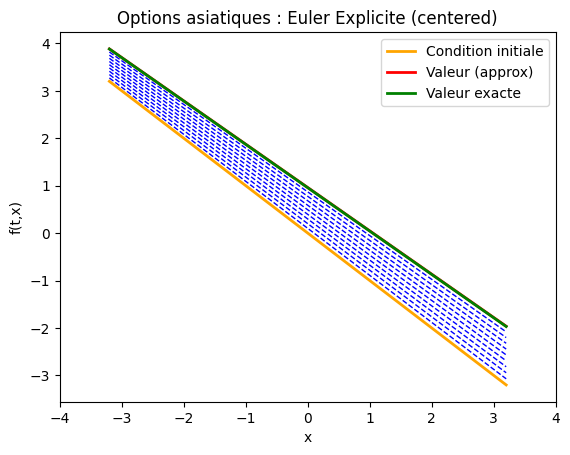

np.int64(0)

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# constants
sigma = 0.3
r = 0.09
T= 1
N = 10
J = 10

# extremes of the problems
Xmin= -4
Xmax = 4

# we leave out also the first since we have dirlichet on bouth ends
x = np.linspace(Xmin, Xmax, N, endpoint=False)[1:]
N_inner = N - 1

h = x[1] -x[0]
k = T/J

methode = 0


U0 = -x
Uj = U0.copy()

def g_exact(t, x):
    return -x * np.exp(-r*t) + (1.0 - np.exp(-r*t)) / (r*T)

def g_asian(x):
    return np.maximum(-x, 0.0)

def beta(l,i):
    return (sigma**2 * l[i]**2)/ (h**2)

def alpha(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) - (1/T + r* l[i])/ (2*h)

def gamma(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) + (1/T + r* l[i])/ (2*h)


alpha_vec = np.vectorize(alpha , excluded={0, 'l'})
beta_vec = np.vectorize(beta , excluded={0, 'l'})
gamma_vec = np.vectorize(gamma , excluded={0, 'l'})

def build_A(l):
    # gets us b1 to bn (b0 is excluded since it's not in x)
    N_inner = l.size
    main = beta_vec( l, range(0, N_inner))
    sub  = alpha_vec(l, range(1, N_inner))
    sup=  gamma_vec(l, range(0, N_inner-1))

    A = np.diag(main) + np.diag(sub, k=-1) + np.diag(sup, k=1)

    return A

# fonction pour la definition de la matrice A
def mat_A(sigma, r, x):

    N_in = x.size

    A1 = - 1 / (2.*h*h) * np.diag(np.power(sigma*x, 2)).dot(
        np.eye(N_in,k=-1) - 2. * np.eye(N_in) + np.eye(N_in,k=1) )

    # correction term needed in our case
    corr = 1.0 / T + r * x

    #switched to a centered not an upwind
    A2 = (1.0 /(2*h))* np.diag(corr).dot(np.eye(N_in, k=1) - np.eye(N_in, k=-1))


    return (A1+A2)

def C_special(j):
    vec = np.zeros(N_inner)
    vec[0] = g_exact(j * k, Xmin) * alpha(x,0)
    vec[-1] = g_exact(j * k, Xmax) * gamma(x,N_inner-1)
    return vec

def EE(A, k, U, j):
    B = np.eye(N_inner) - k * A
    return B @ U - k * C_special(j)

def EI(A, k, U, j):
    # implicit uses b at next time
    B = np.eye(N_inner) + k*A

    return np.linalg.solve(B, U - k*C_special(j+1))

def CN(A, k, U, j):
    B1 = np.eye(N_inner) + .5 * k * A
    B2 = np.eye(N_inner) - .5 * k * A
    rhs = B2 @ U - 0.5 * k * (C_special(j)+ C_special(j+1))
    return np.linalg.solve(B1, rhs)

if methode == 0:
    step_forward = EE
elif methode == 1:
    step_forward = EI
elif methode == 2:
    step_forward = CN

if methode == 0:
    nom_methode = "Options asiatiques : Euler Explicite (centered)"
    nom_fichier = "opt_asian_EE_centered.png"
elif methode == 1:
    nom_methode = "Options asiatiques : Euler Implicite (centered)"
    nom_fichier = "opt_asian_EI_centered.png"
elif methode == 2:
    nom_methode = "Options asiatiques : Crank-Nicolson (centered)"
    nom_fichier = "opt_asian_CN_centered.png"



A = build_A(x)
for j in range(J):

    Uj = step_forward(A, k, Uj, j)

    plt.plot(x, Uj, color="blue", linestyle="dashed", linewidth=1)

valin,  = plt.plot(x, U0, color="orange", linestyle="solid", linewidth=2)
valfin, = plt.plot(x, Uj, color="red", linestyle="solid", linewidth=2)
valtrue, = plt.plot(x, g_exact(T, x), color="green", linestyle="solid", linewidth=2)


plt.xlabel("x")
plt.ylabel("f(t,x)")
plt.xlim((Xmin, Xmax))
plt.legend([valin, valfin,valtrue], ["Condition initiale", "Valeur (approx)", "Valeur exacte"])
plt.title(nom_methode)
plt.savefig(nom_fichier)
plt.show()
(np.isclose(build_A( x), mat_A(sigma , r, x)) == 0).sum() #the two methods lead to the same resul

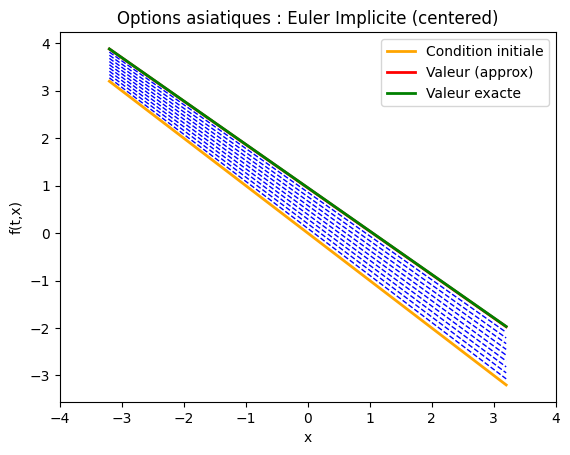

np.int64(0)

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# constants
sigma = 0.3
r = 0.09
T= 1
N = 10
J = 10

# extremes of the problems
Xmin= -4
Xmax = 4

# we leave out also the first since we have dirlichet on bouth ends
x = np.linspace(Xmin, Xmax, N, endpoint=False)[1:]
N_inner = N - 1

h = x[1] -x[0]
k = T/J

methode = 1


U0 = -x
Uj = U0.copy()

def g_exact(t, x):
    return -x * np.exp(-r*t) + (1.0 - np.exp(-r*t)) / (r*T)

def g_asian(x):
    return np.maximum(-x, 0.0)

def beta(l,i):
    return (sigma**2 * l[i]**2)/ (h**2)

def alpha(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) - (1/T + r* l[i])/ (2*h)

def gamma(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) + (1/T + r* l[i])/ (2*h)


alpha_vec = np.vectorize(alpha , excluded={0, 'l'})
beta_vec = np.vectorize(beta , excluded={0, 'l'})
gamma_vec = np.vectorize(gamma , excluded={0, 'l'})

def build_A(l):
    # gets us b1 to bn (b0 is excluded since it's not in x)
    N_inner = l.size
    main = beta_vec( l, range(0, N_inner))
    sub  = alpha_vec(l, range(1, N_inner))
    sup=  gamma_vec(l, range(0, N_inner-1))

    A = np.diag(main) + np.diag(sub, k=-1) + np.diag(sup, k=1)

    return A

# fonction pour la definition de la matrice A
def mat_A(sigma, r, x):

    N_in = x.size

    A1 = - 1 / (2.*h*h) * np.diag(np.power(sigma*x, 2)).dot(
        np.eye(N_in,k=-1) - 2. * np.eye(N_in) + np.eye(N_in,k=1) )

    # correction term needed in our case
    corr = 1.0 / T + r * x

    #switched to a centered not an upwind
    A2 = (1.0 /(2*h))* np.diag(corr).dot(np.eye(N_in, k=1) - np.eye(N_in, k=-1))


    return (A1+A2)

def C_special(j):
    vec = np.zeros(N_inner)
    vec[0] = g_exact(j * k, Xmin) * alpha(x,0)
    vec[-1] = g_exact(j * k, Xmax) * gamma(x,N_inner-1)
    return vec

def EE(A, k, U, j):
    B = np.eye(N_inner) - k * A
    return B @ U - k * C_special(j)

def EI(A, k, U, j):
    # implicit uses b at next time
    B = np.eye(N_inner) + k*A

    return np.linalg.solve(B, U - k*C_special(j+1))

def CN(A, k, U, j):
    B1 = np.eye(N_inner) + .5 * k * A
    B2 = np.eye(N_inner) - .5 * k * A
    rhs = B2 @ U - 0.5 * k * (C_special(j)+ C_special(j+1))
    return np.linalg.solve(B1, rhs)

if methode == 0:
    step_forward = EE
elif methode == 1:
    step_forward = EI
elif methode == 2:
    step_forward = CN

if methode == 0:
    nom_methode = "Options asiatiques : Euler Explicite (centered)"
    nom_fichier = "opt_asian_EE_centered.png"
elif methode == 1:
    nom_methode = "Options asiatiques : Euler Implicite (centered)"
    nom_fichier = "opt_asian_EI_centered.png"
elif methode == 2:
    nom_methode = "Options asiatiques : Crank-Nicolson (centered)"
    nom_fichier = "opt_asian_CN_centered.png"



A = build_A(x)
for j in range(J):

    Uj = step_forward(A, k, Uj, j)

    plt.plot(x, Uj, color="blue", linestyle="dashed", linewidth=1)

valin,  = plt.plot(x, U0, color="orange", linestyle="solid", linewidth=2)
valfin, = plt.plot(x, Uj, color="red", linestyle="solid", linewidth=2)
valtrue, = plt.plot(x, g_exact(T, x), color="green", linestyle="solid", linewidth=2)


plt.xlabel("x")
plt.ylabel("f(t,x)")
plt.xlim((Xmin, Xmax))
plt.legend([valin, valfin,valtrue], ["Condition initiale", "Valeur (approx)", "Valeur exacte"])
plt.title(nom_methode)
plt.savefig(nom_fichier)
plt.show()
(np.isclose(build_A( x), mat_A(sigma , r, x)) == 0).sum() #the two methods lead to the same resul

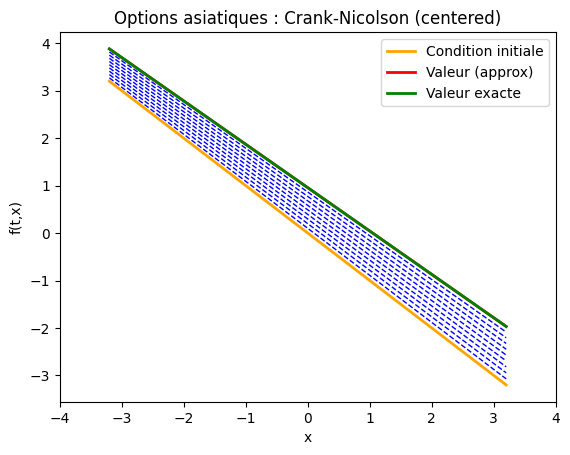

np.int64(0)

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# constants
sigma = 0.3
r = 0.09
T= 1
N = 10
J = 10

# extremes of the problems
Xmin= -4
Xmax = 4

# we leave out also the first since we have dirlichet on bouth ends
x = np.linspace(Xmin, Xmax, N, endpoint=False)[1:]
N_inner = N - 1

h = x[1] -x[0]
k = T/J

methode = 2


U0 = -x
Uj = U0.copy()

def g_exact(t, x):
    return -x * np.exp(-r*t) + (1.0 - np.exp(-r*t)) / (r*T)

def g_asian(x):
    return np.maximum(-x, 0.0)

def beta(l,i):
    return (sigma**2 * l[i]**2)/ (h**2)

def alpha(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) - (1/T + r* l[i])/ (2*h)

def gamma(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) + (1/T + r* l[i])/ (2*h)


alpha_vec = np.vectorize(alpha , excluded={0, 'l'})
beta_vec = np.vectorize(beta , excluded={0, 'l'})
gamma_vec = np.vectorize(gamma , excluded={0, 'l'})

def build_A(l):
    # gets us b1 to bn (b0 is excluded since it's not in x)
    N_inner = l.size
    main = beta_vec( l, range(0, N_inner))
    sub  = alpha_vec(l, range(1, N_inner))
    sup=  gamma_vec(l, range(0, N_inner-1))

    A = np.diag(main) + np.diag(sub, k=-1) + np.diag(sup, k=1)

    return A

# fonction pour la definition de la matrice A
def mat_A(sigma, r, x):

    N_in = x.size

    A1 = - 1 / (2.*h*h) * np.diag(np.power(sigma*x, 2)).dot(
        np.eye(N_in,k=-1) - 2. * np.eye(N_in) + np.eye(N_in,k=1) )

    # correction term needed in our case
    corr = 1.0 / T + r * x

    #switched to a centered not an upwind
    A2 = (1.0 /(2*h))* np.diag(corr).dot(np.eye(N_in, k=1) - np.eye(N_in, k=-1))


    return (A1+A2)

def C_special(j):
    vec = np.zeros(N_inner)
    vec[0] = g_exact(j * k, Xmin) * alpha(x,0)
    vec[-1] = g_exact(j * k, Xmax) * gamma(x,N_inner-1)
    return vec

def EE(A, k, U, j):
    B = np.eye(N_inner) - k * A
    return B @ U - k * C_special(j)

def EI(A, k, U, j):
    # implicit uses b at next time
    B = np.eye(N_inner) + k*A

    return np.linalg.solve(B, U - k*C_special(j+1))

def CN(A, k, U, j):
    B1 = np.eye(N_inner) + .5 * k * A
    B2 = np.eye(N_inner) - .5 * k * A
    rhs = B2 @ U - 0.5 * k * (C_special(j)+ C_special(j+1))
    return np.linalg.solve(B1, rhs)

if methode == 0:
    step_forward = EE
elif methode == 1:
    step_forward = EI
elif methode == 2:
    step_forward = CN

if methode == 0:
    nom_methode = "Options asiatiques : Euler Explicite (centered)"
    nom_fichier = "opt_asian_EE_centered.png"
elif methode == 1:
    nom_methode = "Options asiatiques : Euler Implicite (centered)"
    nom_fichier = "opt_asian_EI_centered.png"
elif methode == 2:
    nom_methode = "Options asiatiques : Crank-Nicolson (centered)"
    nom_fichier = "opt_asian_CN_centered.png"



A = build_A(x)
for j in range(J):

    Uj = step_forward(A, k, Uj, j)

    plt.plot(x, Uj, color="blue", linestyle="dashed", linewidth=1)

valin,  = plt.plot(x, U0, color="orange", linestyle="solid", linewidth=2)
valfin, = plt.plot(x, Uj, color="red", linestyle="solid", linewidth=2)
valtrue, = plt.plot(x, g_exact(T, x), color="green", linestyle="solid", linewidth=2)


plt.xlabel("x")
plt.ylabel("f(t,x)")
plt.xlim((Xmin, Xmax))
plt.legend([valin, valfin,valtrue], ["Condition initiale", "Valeur (approx)", "Valeur exacte"])
plt.title(nom_methode)
plt.savefig(nom_fichier)
plt.show()
(np.isclose(build_A( x), mat_A(sigma , r, x)) == 0).sum() #the two methods lead to the same resul

##4.2. Numerical solution to the correct PDE


In this section we solve the *correct* reduced PDE on a truncated domain $[X_{\min},X_{\max}]$ with Dirichlet conditions $f(t,X_{\min})=g(t)$ and $f(t,X_{\max})=0$, and initial condition $f(0,x)=\max(x,0)$. The spatial operator is discretised with centered finite differences, while time stepping is performed with the selected scheme (EE/IE/CN).


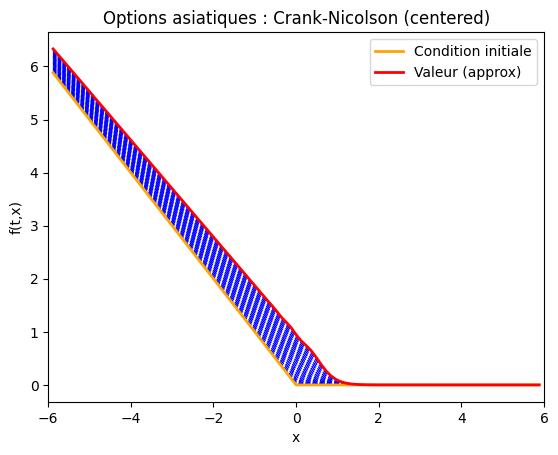

np.int64(0)

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# constants
sigma = 0.3
r = 0.09
T=1
N = 100
J = 20

# extremes of the problems
Xmin= -6
Xmax = 6

# we leave out also the first since we have dirlichet on bouth ends
x = np.linspace(Xmin, Xmax, N, endpoint=False)[1:]
N_inner = N - 1

h = x[1] -x[0]
k = T/J

methode = 2


U0 = np.maximum(-x, 0)
Uj = U0.copy()

def g_exact(t, x):
    return -x * np.exp(-r*t) + (1.0 - np.exp(-r*t)) / (r*T)

def g_asian(x):
    return np.maximum(-x, 0.0)

def beta(l,i):
    return (sigma**2 * l[i]**2)/ (h**2)

def alpha(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) - (1/T + r* l[i])/ (2*h)

def gamma(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) + (1/T + r* l[i])/ (2*h)


alpha_vec = np.vectorize(alpha , excluded={0, 'l'})
beta_vec = np.vectorize(beta , excluded={0, 'l'})
gamma_vec = np.vectorize(gamma , excluded={0, 'l'})

def build_A(l):
    # gets us b1 to bn (b0 is excluded since it's not in x)
    N_inner = l.size
    main = beta_vec( l, range(0, N_inner))
    sub  = alpha_vec(l, range(1, N_inner))
    sup=  gamma_vec(l, range(0, N_inner-1))

    A = np.diag(main) + np.diag(sub, k=-1) + np.diag(sup, k=1)

    return A

# fonction pour la definition de la matrice A
def mat_A(sigma, r, x):

    N_in = x.size

    A1 = - 1 / (2.*h*h) * np.diag(np.power(sigma*x, 2)).dot(
        np.eye(N_in,k=-1) - 2. * np.eye(N_in) + np.eye(N_in,k=1) )

    # correction term needed in our case
    corr = 1.0 / T + r * x

    #switched to a centered not an upwind
    A2 = (1.0 /(2*h))* np.diag(corr).dot(np.eye(N_in, k=1) - np.eye(N_in, k=-1))


    return (A1+A2)

def C(j):
    vec = np.zeros(N_inner)
    vec[0] = g_exact(j * k, Xmin) * alpha(x,0)
    return vec

def EE(A, k, U, j):
    B = np.eye(N_inner) - k * A
    return B @ U - k * C(j)

def EI(A, k, U, j):
    # implicit uses b at next time
    B = np.eye(N_inner) + k*A

    return np.linalg.solve(B, U - k*C(j+1))

def CN(A, k, U, j):
    B1 = np.eye(N_inner) + .5 * k * A
    B2 = np.eye(N_inner) - .5 * k * A
    rhs = B2 @ U - 0.5 * k * (C(j)+ C(j+1))
    return np.linalg.solve(B1, rhs)

if methode == 0:
    step_forward = EE
elif methode == 1:
    step_forward = EI
elif methode == 2:
    step_forward = CN

if methode == 0:
    nom_methode = "Options asiatiques : Euler Explicite (centered)"
    nom_fichier = "opt_asian_EE_centered.png"
elif methode == 1:
    nom_methode = "Options asiatiques : Euler Implicite (centered)"
    nom_fichier = "opt_asian_EI_centered.png"
elif methode == 2:
    nom_methode = "Options asiatiques : Crank-Nicolson (centered)"
    nom_fichier = "opt_asian_CN_centered.png"



A = build_A(x)
for j in range(J):

    Uj = step_forward(A, k, Uj, j)

    plt.plot(x, Uj, color="blue", linestyle="dashed", linewidth=1)

valin,  = plt.plot(x, U0, color="orange", linestyle="solid", linewidth=2)
valfin, = plt.plot(x, Uj, color="red", linestyle="solid", linewidth=2)

plt.xlabel("x")
plt.ylabel("f(t,x)")
plt.xlim((Xmin, Xmax))
plt.legend([valin, valfin], ["Condition initiale", "Valeur (approx)"])
plt.title(nom_methode)
plt.savefig(nom_fichier)
plt.show()
(np.isclose(build_A( x), mat_A(sigma , r, x)) == 0).sum() #the two methods lead to the same resul

# 5. Stability  near 0

## Explicit Euler

Let's study the stability of the Explicit Euler, we have seen before that:

$$
\begin{align}
U^{j+1}_{i}  & = +U^{j}_{i}- U^{j}_{i}k\beta _{i}-U^{j}_{i-1}k\alpha _{i}-U^{j}_{i+1}k\gamma _{i}  \\
 & =U^{j}_{i}\underbrace{ \left[ 1  -\frac{\left(   k \sigma^{2} x_{i}^{2}\right)}{h^{2}}  \right] }_{ B_{i,i} }  + U^{j}_{i-1}\underbrace{ k\left[  \frac{1}{2}  \frac{\sigma^{2} x_{i}^{2}}{h^{2}}  + \frac{\left( \frac{1}{T}+rx_{i} \right)}{2h}\right]  }_{ B_{i,i-1} }+ U^{j}_{i+1} \underbrace{ k \left[ +  \frac{1}{2}  \frac{\sigma^{2} x_{i}^{2}}{h^{2}}  - \frac{\left( \frac{1}{T}+rx_{i} \right)}{2h} \right] }_{ B_{i,i+1} } \\
\end{align}
$$

Since our PDE can be written as:
$$
U^{j+1}= B\,U^{j},
$$
we can study the stabiltiy through a sufficient condition directly on the matrix B.

We observe that the sum of the three coefficients is
$$
( B_{i,i})+( B_{i,i-1})+( B_{i,i+1})=1.
$$

Hence, a sufficient condition for strong stability in the $\|B\|_\infty$ norm is that all coefficients of \(B\) are non-negative, because in this case we have:
$$
\left\| |B|  \right\| _{\infty} = \max_{i}\sum_{m}^{} |B_{im}| = \max_{i}\sum_{m}^{} B_{im} = 1
$$


Since $B_{i, i-1}>0$ is always satisfied. The two nontrivial inequalities are:


$$
\boxed{B_{i,i+1}\ge 0}
\quad\Longleftrightarrow\quad
\boxed{\frac{\sigma^2 x_i^2}{h}\ge \Big(\frac{1}{T}+r\,x_i\Big)},
$$

and
$$
\boxed{B_{i,i}\ge 0}
\quad\Longleftrightarrow\quad
\boxed{\frac{k}{h^2}\le \frac{1}{\sigma^2 x_i^2}}.
$$

This last one ofcourse is very similar to the CFL condition.
  
  
**Remark (breakdown of the first sufficient condition near $x=0$ ).**

Among the two nontrivial inequalities, the most problematic (when we are near $x=0$) is

$$
B_{i,i+1}\geq0
\quad\Longleftrightarrow\quad
\frac{\sigma^2 x_i^2}{h}\ge \Big(\frac{1}{T}+r\,x_i\Big).
$$

  

Indeed, as $x_i \to 0$, the diffusion contribution on the left-hand side behaves like $\sigma^2 x_i^2$ and therefore becomes very small, whereas the drift term on the right-hand side satisfies

$$
\frac{1}{T}+r\,x_i \approx \frac{1}{T},
$$

which remains of order $1$. Hence, for nodes sufficiently close to $x=0$, the inequality above cannot be satisfied. Consequently, near $x=0$ the sufficient strong-stability criterion based on the nonnegativity of the coefficients of $B$ breaks down.

  

**Consequences for simulations.**

Since the sufficient strong-stability condition fails near $x=0$, some coefficients in the update matrix $B$ may become negative in that region. Numerically, this typically results in a loss of monotonicity (discrete maximum principle): small perturbations and discretization errors can be amplified locally, producing **spurious oscillations** near $x=0$ and possibly **non-physical values** (e.g., negative values for a quantity that should remain nonnegative). In practice, the computed solution becomes more sensitive to the choice of $(h,k)$, and reducing the time step alone may not remove these artifacts unless the spatial discretization (or the treatment near $x=0$) is modified.


We deliberately put T small (ie $T=0.01$) so that the following inequality **doesn't hold** $\frac{\sigma^2 x_i^2}{h}\ge \Big(\frac{1}{T}+r\,x_i\Big)$. In this way we can observe that for the EE we can see a loss of monotonicity of the solution around 0.

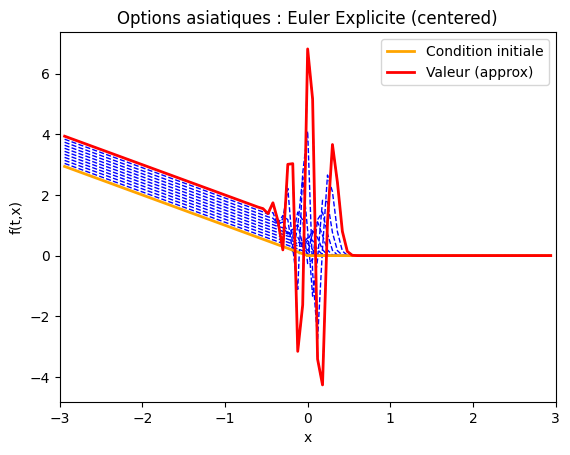

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# constants
sigma  = 0.3
r      = 0.10
T      = 0.01
N      = 100
J      = 10

# extremes of the problems
Xmin   = -3
Xmax   = 3

# we leave out also the first since we have dirlichet on bouth ends
x_stability = np.linspace(Xmin, Xmax, N, endpoint=False)[1:]
N_inner= N - 1
h      = x_stability[1] - x_stability[0]
k      = T/J

methode= 0


U0 = np.maximum(-x_stability, 0)
Uj = U0.copy()

def g_exact(t, x):
    return -x * np.exp(-r*t) + (1.0 - np.exp(-r*t)) / (r*T)

def g_asian(x):
    return np.maximum(-x, 0.0)

def beta(l,i):
    return (sigma**2 * l[i]**2)/ (h**2)

def alpha(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) - (1/T + r* l[i])/ (2*h)

def gamma(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) + (1/T + r* l[i])/ (2*h)


alpha_vec = np.vectorize(alpha , excluded={0, 'l'})
beta_vec = np.vectorize(beta , excluded={0, 'l'})
gamma_vec = np.vectorize(gamma , excluded={0, 'l'})

def build_A(l):
    # gets us b1 to bn (b0 is excluded since it's not in x)
    N_inner = l.size
    main = beta_vec( l, range(0, N_inner))
    sub  = alpha_vec(l, range(1, N_inner))
    sup=  gamma_vec(l, range(0, N_inner-1))

    A = np.diag(main) + np.diag(sub, k=-1) + np.diag(sup, k=1)

    return A


def C(j):
    vec = np.zeros(N_inner)
    vec[0] = g_exact(j * k, Xmin) * alpha(x_stability,0)
    return vec

def EE(A, k, U, j):
    B = np.eye(N_inner) - k * A
    return B @ U - k * C(j)

def EI(A, k, U, j):
    # implicit uses b at next time
    B = np.eye(N_inner) + k*A

    return np.linalg.solve(B, U - k*C(j+1))

def CN(A, k, U, j):
    B1 = np.eye(N_inner) + .5 * k * A
    B2 = np.eye(N_inner) - .5 * k * A
    rhs = B2 @ U - 0.5 * k * (C(j)+ C(j+1))
    return np.linalg.solve(B1, rhs)

if methode == 0:
    step_forward = EE
elif methode == 1:
    step_forward = EI
elif methode == 2:
    step_forward = CN

if methode == 0:
    nom_methode = "Options asiatiques : Euler Explicite (centered)"
    nom_fichier = "opt_asian_EE_centered.png"
elif methode == 1:
    nom_methode = "Options asiatiques : Euler Implicite (centered)"
    nom_fichier = "opt_asian_EI_centered.png"
elif methode == 2:
    nom_methode = "Options asiatiques : Crank-Nicolson (centered)"
    nom_fichier = "opt_asian_CN_centered.png"



A = build_A(x_stability)
for j in range(J):

    Uj = step_forward(A, k, Uj, j)

    plt.plot(x_stability, Uj, color="blue", linestyle="dashed", linewidth=1)

valin,  = plt.plot(x_stability, U0, color="orange", linestyle="solid", linewidth=2)
valfin, = plt.plot(x_stability, Uj, color="red", linestyle="solid", linewidth=2)

plt.xlabel("x")
plt.ylabel("f(t,x)")
plt.xlim((Xmin, Xmax))
plt.legend([valin, valfin], ["Condition initiale", "Valeur (approx)"])
plt.title(nom_methode)
plt.savefig(nom_fichier)
plt.show()

## Implicit Euler

With easy computations, using the centered differences and rearranging all $j+1$ terms on the left, we obtain the tridiagonal system
$$
U_{i-1}^{j+1}\underbrace{\left[-\left(\frac{k\sigma^2 x_i^2}{2h^2}+\frac{k}{2h}\Big(\frac1T+r x_i\Big)\right)\right]}_{B_{i,i-1}}
\;+\;
U_{i}^{j+1}\underbrace{\left[1+2\frac{k\sigma^2 x_i^2}{2h^2}\right]}_{B_{i,i}}
\;+\;
U_{i+1}^{j+1}\underbrace{\left[-\left(\frac{k\sigma^2 x_i^2}{2h^2}-\frac{k}{2h}\Big(\frac1T+r x_i\Big)\right)\right]}_{B_{i,i+1}}
\;=\;
U_i^{j},
\qquad i=1,\dots,N-1.
$$


where we have indicated with B the matrix such that:
$$
B\,U^{j+1}=U^{j},
$$
and so, in order to study the strong stability, we need to study the norm of the inverse of B

The strategy is to prove that $B$ is **monotone** (hence $B^{-1}\ge 0$), then use a discrete maximum principle to bound $\|B^{-1}\|_\infty$.



The sum for each row is :
$$
\sum_{i} B_{i} = 1.
$$

We want prove monotonicity for $B$ i.e.:
$$
BU ≥ 0 \Rightarrow U\geq 0.
$$

This implies in particular that $B^{-1} \geq 0$ (and therfore the method is well-defined and satifies a discrete comparison principle)

#### Discrete minimum argument

Assume $U\in\mathbb{R}^{N-1}$ satisfies
$$
BU\ge 0.
$$

Let

$$
m := \min_{1\le j\le N-1} U_j,
\qquad\text{and choose } i \text{ such that } U_i=m.
$$

Then

$$
U_{i-1}\ge m,\qquad U_i=m,\qquad U_{i+1}\ge m.
$$

Now we write explicitly the $i$-th component of $BU$:

$$
0\le (BU)_i
=B_{i,i-1}\,U_{i-1} + B_{i,i} U_i +B_{i,i+1}U_{i+1}
$$

To bound the right-hand side **from above** by something involving only $m$, we need the off-diagonal coefficients to be **nonpositive**.

Here we already have

$$
B_{i,i-1} \le 0 \quad\text{always,}
$$

and we require also

$$
B_{i,i+1}\le 0
\quad\Longleftrightarrow\quad
\boxed{\ \frac{\sigma^2 x_i^2}{h}\ \ge\ \Big(\frac1T+r x_i\Big)\ }
$$
(exactly like before)

  
Under this condition, both off-diagonal coefficients are $\le 0$, hence (since $U_{i-1}\ge m$ and $U_{i+1}\ge m$)

$$
B_{i,i-1}\,U_{i-1}\ \le\ B_{i,i-1}\,m,
\qquad
B_{i,i+1}\,U_{i+1}\ \le\ B_{i,i+1}\,m.
$$

Moreover, since $U_i=m$,

$$
B_{i,i}U_i=B_{i,i}m.
$$

  

Putting these together we obtain

$$
0\le (BU)_i
\le \sum_{i}^{}B_{i,c} m = m.
$$

Therefore,

$$
m\ge 0.
$$

Since $m$ is the minimum component of $U$, this implies

$$
U_j\ge m\ge 0 \quad\forall j=1,\dots,N-1,
$$

i.e.

$$
U\ge 0.
$$

  

Hence we have proved:


 **If $\frac{\sigma^{2}x_{i}^{2}}{h}\geq\left( \frac{1}{T} + rx_{i} \right)$ for all interior nodes $i$, then $B$ is monotone**, i.e.

$$
BU\ge 0 \ \Rightarrow\ U\ge 0,
$$
and in particular $B^{-1}\ge 0$.

### Discrete maximum principle and bound on $\|B^{-1}\|_\infty$

Assume now $\alpha_i\ge\beta_i$ so that $B^{-1}\ge 0$.
Let $V\ge 0$ and set $U=B^{-1}V$, i.e. $BU=V$.
Let $M=\max_{1\le m\le N-1}U_m$ and choose $i$ such that $U_i=M$.
Since $U_{i-1}\le M$ and $U_{i+1}\le M$, and since $B_{i,i\pm1}\le 0$, we have
$$
V_i
= B_{i,i-1}U_{i-1}+B_{i,i}U_i+B_{i,i+1}U_{i+1}
\ge B_{i,i-1}M+B_{i,i}M+B_{i,i+1}M
= (B\mathbf{1})_i\,M
= 1\cdot M,
$$
because the row sum equals $1$.
Thus $M\le V_i\le \|V\|_\infty$, hence
$$
\|U\|_\infty \le \|V\|_\infty
\quad\Longrightarrow\quad
\boxed{\ \|B^{-1}\|_\infty \le 1\ }.
$$

So, **under the sufficient condition $\alpha_i\ge\beta_i$**, the implicit Euler (centered) scheme is **strongly stable in $\|\cdot\|_\infty$**:
$$
\|U^{j+1}\|_\infty \le \|U^j\|_\infty.
$$







#6. Testing empirically the theoretical order

The theoretical orders for our method, since the equation is so similar to the one seen in class, remains the same i.e.:


| Method   | order in space | order in time |
| -------- | -------------: | ------------: |
| EE (DFC) |              2 |             1 |
| IE (DFC) |              2 |             1 |
| CN (DFC) |              2 |             2 |

Even if the scheme is formally of the orders above, the measured order comes out  be lower beacuse:
- the initial payoff has a kink (nonsmoothness near $x=0$),
- one measures error in $\|\cdot\|_\infty$ (very sensitive to localized oscillations),
- We also couldn't measure the empirical order in time of the EE beacuse it becomes unstable when N is large and J is small (The CFL-type stability condition is violated)


To estimate the empirical convergence order, we first compute a reference solution on a very fine grid, $N_{\mathrm{ref}}=1024$ and $J_{\mathrm{ref}}=1024$. We then treat this reference solution as the ground truth.
To measure the **spatial** order, we fix the time discretisation $J$ and run the method on a sequence of spatial grids $N=2^m$. To measure the **temporal** order, we fix the spatial discretisation $N$ and run the method on a sequence of time grids $J=2^m$ ( for both $m \in \{1,...,5\}$  
 Using powers of two ensures that each coarse spatial grid is nested in the reference grid, so the numerical solutions can be compared at the same spatial nodes (no interpolation). The empirical order is then obtained from the error decay between successive refinements (mathematicaly we take the last two errors of the grid and the order  $ p =  log_2(E_{2^4}/E_{2^5}), q =  log_2(E_{2^4}/E_{2^5})$).



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# constants
sigma = 0.3
r = 0.09
T =  1

# extremes of the problems
Xmin= -6
Xmax = 6

#cs : correct solution
#power of two so we can get an accurate comparison between the time nodes
Ncs = 1024
Jcs = 1024

# we leave out also the first since we have dirlichet on bouth ends
xcs = np.linspace(Xmin, Xmax, Ncs, endpoint=False)[1:]
N_innercs = Ncs - 1

h = xcs[1] -xcs[0]
k = T/Jcs
methode = 2

def g_exact(t, l):
    return -l * np.exp(-r*t) + (1.0 - np.exp(-r*t)) / (r*T)

def g_asian(l):
    return np.maximum(-l, 0.0)

def beta(l,i):
    return (sigma**2 * l[i]**2)/ (h**2)

def alpha(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) - (1/T + r* l[i])/ (2*h)

def gamma(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) + (1/T + r* l[i])/ (2*h)


alpha_vec = np.vectorize(alpha , excluded={0, 'l'})
beta_vec = np.vectorize(beta , excluded={0, 'l'})
gamma_vec = np.vectorize(gamma , excluded={0, 'l'})

def build_A(l):
    # gets us b1 to bn (b0 is excluded since it's not in x)
    N_alpha = l.size
    main = beta_vec( l, range(0, N_alpha))
    sub  = alpha_vec(l, range(1, N_alpha))
    sup=  gamma_vec(l, range(0, N_alpha-1))

    A = np.diag(main) + np.diag(sub, k=-1) + np.diag(sup, k=1)

    return A


def C(j):
    vec = np.zeros(N_innercs)
    vec[0] = g_exact(j * k, Xmin) * alpha(xcs,0)
    return vec

def EE(A, k, U, j):
    B = np.eye(N_innercs) - k * A
    return B @ U - k * C(j)

def EI(A, k, U, j):
    # implicit uses b at next time
    B = np.eye(N_innercs) + k*A

    return np.linalg.solve(B, U - k*C(j+1))

def CN(A, k, U, j):
    B1 = np.eye(N_innercs) + .5 * k * A
    B2 = np.eye(N_innercs) - .5 * k * A
    rhs = B2 @ U - 0.5 * k * (C(j)+ C(j+1))
    return np.linalg.solve(B1, rhs)

if methode == 0:
    step_forward = EE
elif methode == 1:
    step_forward = EI
elif methode == 2:
    step_forward = CN

if methode == 0:
    nom_methode = "Options asiatiques : Euler Explicite (centered)"
    nom_fichier = "opt_asian_EE_centered.png"
elif methode == 1:
    nom_methode = "Options asiatiques : Euler Implicite (centered)"
    nom_fichier = "opt_asian_EI_centered.png"
elif methode == 2:
    nom_methode = "Options asiatiques : Crank-Nicolson (centered)"
    nom_fichier = "opt_asian_CN_centered.png"

U0 = np.maximum(-xcs, 0)
Uj = U0.copy()
U = np.zeros((Jcs+1, N_innercs))
U[0,:] = U0
A = build_A(xcs)

for j in range(Jcs):
    Uj = step_forward(A, k, Uj, j)
    U[j+1,:] = Uj

In [ ]:
def erreur_asian(N_f,J_f,method):

  # we leave out also the first since we have dirlichet on bouth ends
  x = np.linspace(Xmin, Xmax, N_f, endpoint=False)[1:]
  N_ = N_f - 1

  h_f = x[1] -x[0]
  k_f = T/J_f
  methode = method

  def beta(l,i):
      return (sigma**2 * l[i]**2)/ (h_f**2)

  def alpha(l,i):
      return -(sigma**2 * l[i]**2 )/ (2*h_f**2) - (1/T + r* l[i])/ (2*h_f)

  def gamma(l,i):
      return -(sigma**2 * l[i]**2 )/ (2*h_f**2) + (1/T + r* l[i])/ (2*h_f)


  alpha_vec = np.vectorize(alpha , excluded={0, 'l'})
  beta_vec = np.vectorize(beta , excluded={0, 'l'})
  gamma_vec = np.vectorize(gamma , excluded={0, 'l'})

  def build_A(l):
      # gets us b1 to bn (b0 is excluded since it's not in x)
      N_alpha = l.size
      main = beta_vec( l, range(0, N_alpha))
      sub  = alpha_vec(l, range(1, N_alpha))
      sup=  gamma_vec(l, range(0, N_alpha-1))
      A = np.diag(main) + np.diag(sub, k=-1) + np.diag(sup, k=1)
      return A


  def C(j):
      vec = np.zeros(N_)
      vec[0] = g_exact(j * k_f, Xmin) * alpha(x,0)
      return vec



  def EE(A, k_f, U, j):
      B = np.eye(N_) - k_f * A
      return B @ U - k_f * C(j)

  def EI(A, k_f, U, j):
      # implicit uses b at next time
      B = np.eye(N_) + k_f*A

      return np.linalg.solve(B, U - k_f*C(j+1))

  def CN(A, k, U, j):
      B1 = np.eye(N_) + .5 * k_f * A
      B2 = np.eye(N_) - .5 * k_f * A
      rhs = B2 @ U - 0.5 * k_f * (C(j)+ C(j+1))
      return np.linalg.solve(B1, rhs)


  def restrict_thin_to_coarse(U_thin, N_thin, N_coarse,step):
    # U_thin is the thin-grid interior vector (length N_ref-1)
    if J_f == Jcs:
        if Ncs % N_f != 0 :
            raise ValueError("not multiples")
        m =  N_thin // N_coarse
        # coarse interior nodes i=1..N-1 correspond to fine interior indices i*m
        # (so the jumps are of length m)
        # start (inclusive) : end (exclusive) : jump

        return U_thin[(m-1) : m*(N_coarse) : m]   # length N-1

    elif N_f == Ncs :
          if (Jcs) % (J_f) != 0 :
            raise ValueError("not multiples")
          q = Jcs // J_f
          # here all x nodes are preserved the
          # only difference is we take a sparser approx in time
          return U[(step)*q]
    else :
      raise ValueError("something went wrong")


  if methode == 0:
    step_forward_f = EE
  elif methode == 1:
    step_forward_f = EI
  elif methode == 2:
    step_forward_f = CN

  E  = -1
  E2 = 0
  A = build_A(x)

  U0 = np.maximum(-x, 0)
  Uj = U0.copy()

  for j in range(J_f):
      Uj = step_forward_f(A, k_f, Uj, j)
      uj = U[j+1]
      uj = restrict_thin_to_coarse(uj, Ncs, N_f,j+1)
      E = max(E, np.linalg.norm(Uj-uj, np.inf))
      if E > 1000:
          return( "not stable", h_f , k_f)
  #     err_L2  = np.sqrt(h_f * np.sum((Uj-uj)**2))
  #     if err_L2 > 100:
  #         return( "not stable", h_f , k_f)
  #     E2 += k_f * (err_L2**2)
  # E = np.sqrt(E2)
  return E , h_f , k_f

In [ ]:
def erreur_temps(method, graph=True):
# Erreur en fonction du pas en temps, on considere N et bar_x tres grands
# afin de mettre en evidence seulement l'erreur du a la discretisation en T

    N = Ncs
    Jtot = 5

    E_err = np.zeros((Jtot, ))
    k_err = np.zeros((Jtot, ))

    for Jr in range(Jtot):

        E, h, k = erreur_asian(N, 2**(Jr+2),method)
        if E == "not stable":
            return "not stable"
        E_err[Jr] = E
        k_err[Jr] = k
        if graph:
          print(E, h, k )
    if graph:
      plt.figure(figsize=(12,9))
      plt.loglog(k_err, E_err, marker = '.', color='blue', linestyle='none')
      plt.loglog(k_err, (k_err/k_err[-1]*E_err[-1]), color='red', linestyle='solid')

    #p, logC = np.polyfit(np.log(k_err), np.log(E_err), 1)
    p = np.log2(E_err[-2]/E_err[-1])
    return p

0.04973819320571787 0.01171875 0.25
0.02678284754883309 0.01171875 0.125
0.01605904954620832 0.01171875 0.0625
0.0081846747305193 0.01171875 0.03125
0.002859239386612762 0.01171875 0.015625


np.float64(1.517293670234802)

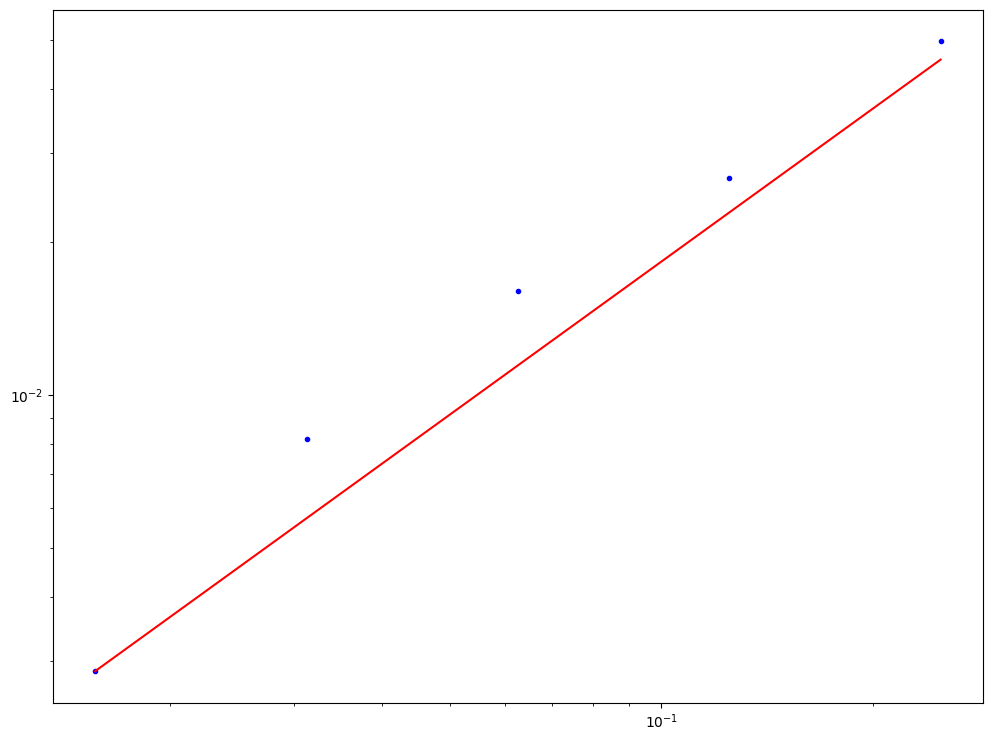

In [ ]:
erreur_temps(2)

In [ ]:
def erreur_espace(method,graph=True):
# Erreur en fonction du pas en espace, on considere J et bar_x tres grands
# afin de mettre en evidence seulement l'erreur du a la discretisation en X

    Ntot = 5
    J = Jcs

    E_err = np.zeros((Ntot, ))
    h_err = np.zeros((Ntot, ))

    for Nr in range(Ntot):
        E, h ,k  = erreur_asian(2**(Nr+2), J, method)

        if E == "not stable":
            return "not stable"
        E_err[Nr] = E
        h_err[Nr] = h
        if graph:
          print(E, h, k )

    if graph:
      plt.figure(figsize=(12,9))
      plt.loglog(h_err, E_err, marker = '.', color='blue', linestyle='none')
      plt.loglog(h_err, h_err/h_err[-1]*E_err[-1], color='red', linestyle='solid')


    q = np.log2(E_err[-2]/E_err[-1])
    return q

0.4001038512491597 3.0 0.0009765625
0.32403283362827573 1.5 0.0009765625
0.1920987525415675 0.75 0.0009765625
0.10517918236636914 0.375 0.0009765625
0.056051847459973325 0.1875 0.0009765625


np.float64(0.9080153569399538)

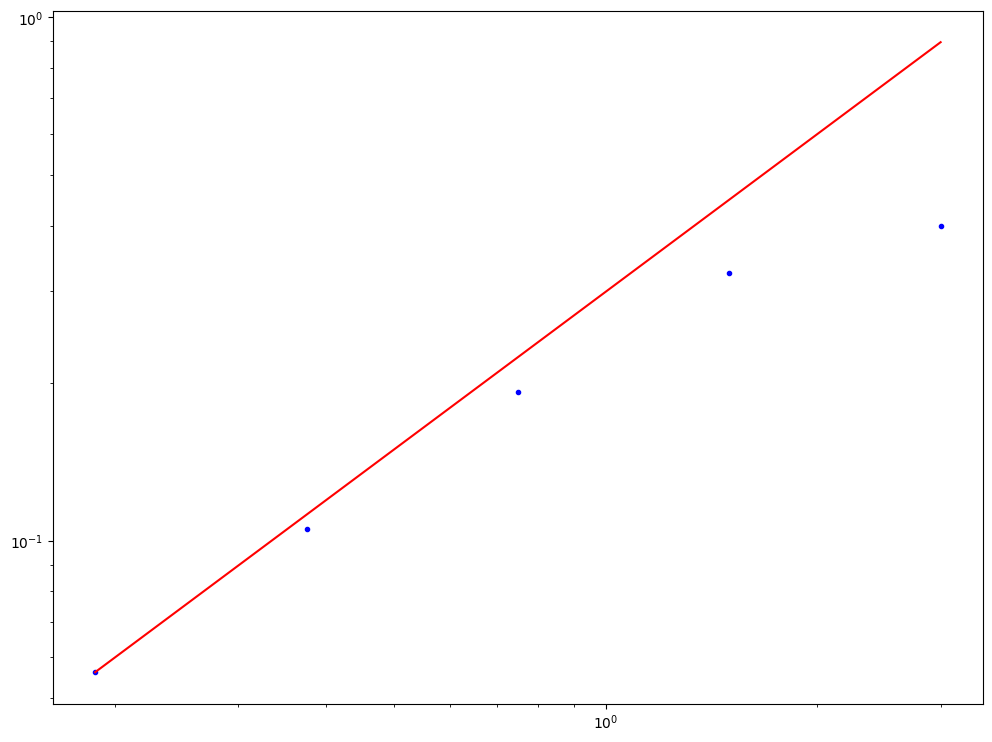

In [ ]:
erreur_espace(2)

In [ ]:
import pandas as pd

df_result = pd.DataFrame(  [[i, i] for i in range(3)] ,columns = ("order in space", "order in time") ,index=  ("EE", "IE", "CN") )
df_result = df_result.apply({
    "order in space": lambda s: erreur_espace(s,False),
    "order in time" : lambda s: erreur_temps(s,False)
})
print(df_result)

    order in space order in time
EE        0.899379    not stable
IE        0.916668      0.742882
CN        0.908015      1.517294


The numerical results are rather disappointing. A different error norm, or a finer discretisation in both space and time (which we could not afford computationally), might have produced more accurate approximations. It is also possible that the domain truncation contributes to the discrepancy. Finally, the lack of smoothness of the payoff at $x=0$ may degrade the observed accuracy and reduce the empirical convergence rate, especially in the $|\cdot|_\infty$ norm.


#7. Compare solution with Rogers & Z. Shi

We then move on to reproducing the results of Rogers and Shi reported in table 1.3.
We match as closely as possible the numerical conditions used in their paper, by taking
the volatility $\sigma = 0.3$, the interest rate $r = 0.09$, and considering the
three strike prices $K \in \{90, 100, 110\}$. The spatial domain is fixed to
$[X_{\min}, X_{\max}] = [-6, 6]$ and we use a spatial step that is even smaller, in the original work they don't notice a big differnence in the solution.


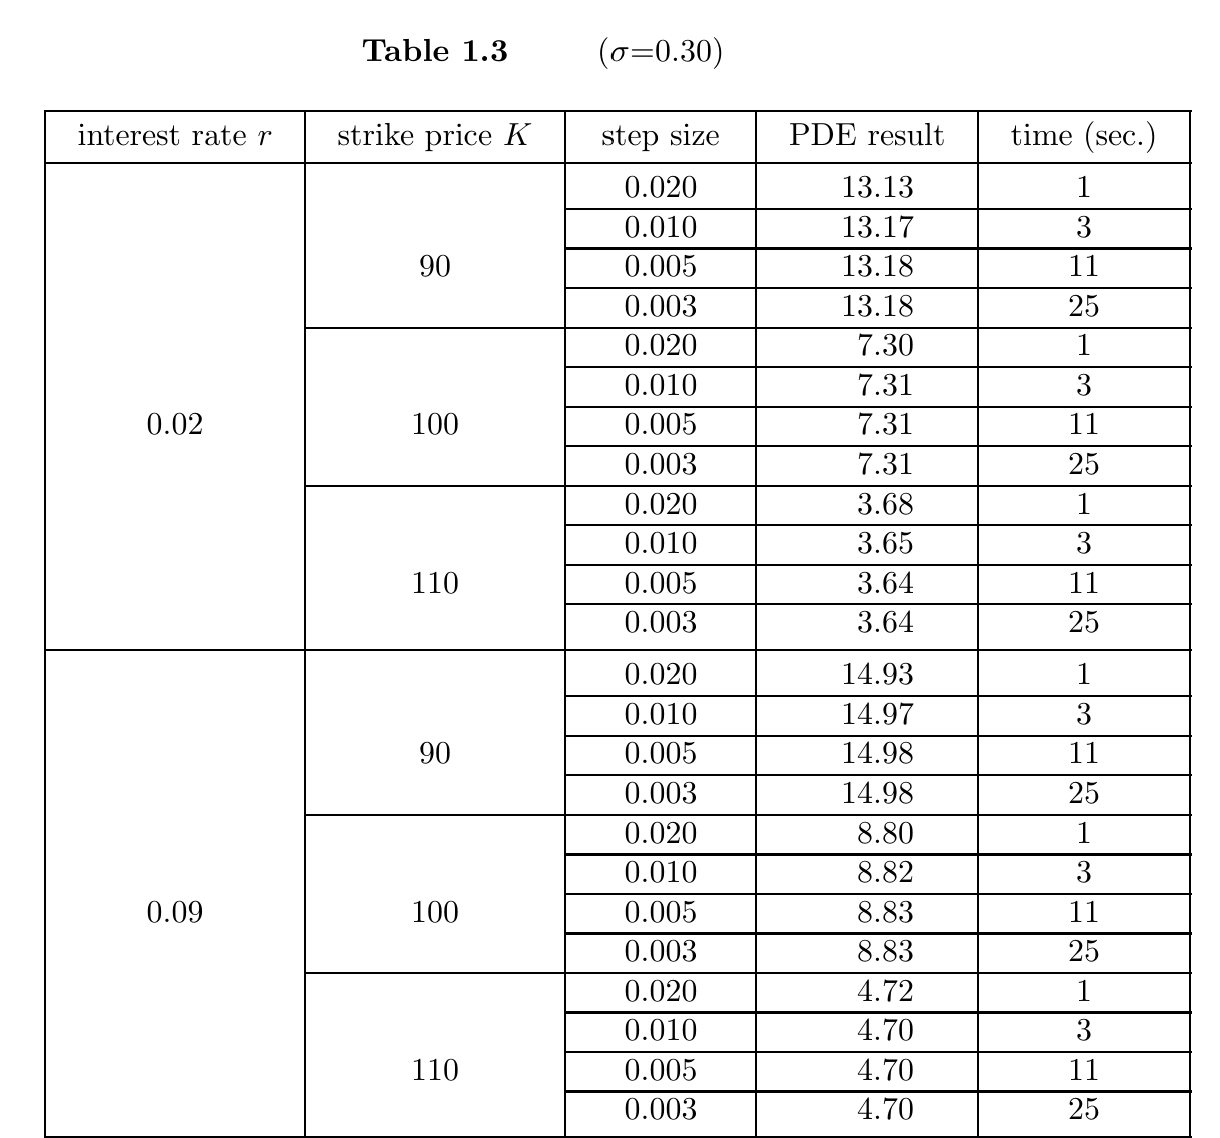

In [ ]:
def option_value( K,Uj, S0, x_grid):
    X_bar  =  K/ S0
    # we interpolate the function and use the identity V(0,S,S )=sf(x,0)
    V_Opt = np.interp( X_bar , x_grid , Uj  )*S0
    return V_Opt

In [ ]:
strike_list = [90, 100 , 110]
S0 = 100
for K in strike_list:
  value  = option_value(K, Uj, S0, xcs)
  print(f"The value of the option is {round(value,2)}")

The value of the option is 14.96
The value of the option is 8.81
The value of the option is 4.7


The values match perfectly with the paper so conferming the correctness of our implementation.

#8. Compare results with $X_{min} = 0$ with $X_{min} <0$

We now compare the option prices obtained with the biased truncation
$X_{\min}=0$ and with the more realistic choice $X_{\min}=-6$. We observe
that the biased scheme always produces a higher price.

Imposing $X_{\min}=0$ amounts to cutting off the
region $x<0$, where the initial condition $f(0,x)=\max(-x,0)$ is strictly positive
and the true solution is relatively large. In our experiments, the price computed with $X_{\min}=0$ is always
below the price obtained with $X_{\min}=-6$, with the discrepancy being more
pronounced for lower strikes $K$, which are more sensitive to the behaviour
of $f$ on the negative part of the domain. Indeed, recalling that
$$
V(0,S_0,S_0) = S_0\,f(T,\bar x), \qquad \bar x = \frac{K}{S_0},
$$
smaller values of $K$ correspond to values of $\bar x$ closer to the left
boundary, where the approximation of $f$ is the least accurate.

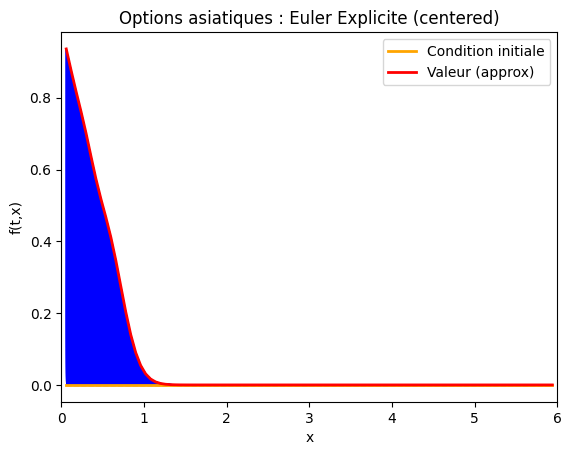

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# constants
sigma = 0.3
r = 0.09
T =  0.1

# extremes of the problems
Xmin= -0
Xmax = 6

#cs : correct solution
#power of two so we can get an accurate comparison between the time nodes
Ncut = 100
Jcut = 1000

# we leave out also the first since we have dirlichet on bouth ends
xcut = np.linspace(Xmin, Xmax, Ncut, endpoint=False)[1:]
N_innercs = Ncut - 1

h = xcut[1] -xcut[0]
k = T/Jcut
methode = 0

def g_exact(t, l):
    return -l * np.exp(-r*t) + (1.0 - np.exp(-r*t)) / (r*T)

def g_asian(l):
    return np.maximum(-l, 0.0)

def beta(l,i):
    return (sigma**2 * l[i]**2)/ (h**2)

def alpha(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) - (1/T + r* l[i])/ (2*h)

def gamma(l,i):
    return -(sigma**2 * l[i]**2 )/ (2*h**2) + (1/T + r* l[i])/ (2*h)


alpha_vec = np.vectorize(alpha , excluded={0, 'l'})
beta_vec = np.vectorize(beta , excluded={0, 'l'})
gamma_vec = np.vectorize(gamma , excluded={0, 'l'})

def build_A(l):
    # gets us b1 to bn (b0 is excluded since it's not in x)
    N_alpha = l.size
    main = beta_vec( l, range(0, N_alpha))
    sub  = alpha_vec(l, range(1, N_alpha))
    sup=  gamma_vec(l, range(0, N_alpha-1))

    A = np.diag(main) + np.diag(sub, k=-1) + np.diag(sup, k=1)

    return A


def C(j):
    vec = np.zeros(N_innercs)
    vec[0] = g_exact(j * k, Xmin) * alpha(xcut,0)
    return vec

def EE(A, k, U, j):
    B = np.eye(N_innercs) - k * A
    return B @ U - k * C(j)

def EI(A, k, U, j):
    # implicit uses b at next time
    B = np.eye(N_innercs) + k*A

    return np.linalg.solve(B, U - k*C(j+1))

def CN(A, k, U, j):
    B1 = np.eye(N_innercs) + .5 * k * A
    B2 = np.eye(N_innercs) - .5 * k * A
    rhs = B2 @ U- 0.5 * k * (C(j)+ C(j+1))
    return np.linalg.solve(B1, rhs)

if methode == 0:
    step_forward = EE
elif methode == 1:
    step_forward = EI
elif methode == 2:
    step_forward = CN

if methode == 0:
    nom_methode = "Options asiatiques : Euler Explicite (centered)"
    nom_fichier = "opt_asian_EE_centered.png"
elif methode == 1:
    nom_methode = "Options asiatiques : Euler Implicite (centered)"
    nom_fichier = "opt_asian_EI_centered.png"
elif methode == 2:
    nom_methode = "Options asiatiques : Crank-Nicolson (centered)"
    nom_fichier = "opt_asian_CN_centered.png"

U0cut = np.maximum(-xcut, 0)
Ujcut = U0cut.copy()
A = build_A(xcut)

for j in range(Jcut):
    Ujcut = step_forward(A, k, Ujcut, j)
    plt.plot(xcut, Ujcut, color="blue", linestyle="dashed", linewidth=1)


valin,  = plt.plot(xcut, U0cut, color="orange", linestyle="solid", linewidth=2)
valfin, = plt.plot(xcut, Ujcut, color="red", linestyle="solid", linewidth=2)

plt.xlabel("x")
plt.ylabel("f(t,x)")
plt.xlim((Xmin, Xmax))
plt.legend([valin, valfin], ["Condition initiale", "Valeur (approx)"])
plt.title(nom_methode)
plt.savefig(nom_fichier)
plt.show()




In [ ]:
strike_list = [  80 , 90, 100 ,110, 120,130 ,140 ,150]
S0 = 100

for K in strike_list:
  print(f"The difference between option prices is {round(option_value(K,Uj,S0,xcs )-option_value(K,Ujcut , S0,xcut),2)}")

The difference between option prices is 4.61
The difference between option prices is 5.94
The difference between option prices is 4.95
The difference between option prices is 3.31
The difference between option prices is 1.89
The difference between option prices is 0.93
The difference between option prices is 0.42
The difference between option prices is 0.18
